## Student Placement Prediction Using Logistic Regression

## Project Objective

The objective of this project is to predict whether a student will be placed or not placed based on academic performance, skills, internships, projects, and other student-related factors.

### Dataset
- Training data: 45,000 students
- Testing data: 5,000 students
- Target variable: `Placement_Status`

The dataset is already divided into training and testing sets.

## Importing Libraries

In [44]:
import pandas as pd

## Loading Dataset

In [45]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")


## Understand the Data

In [46]:
# Display the first 5 rows
print(train_df.head())
print(test_df.head())

   Student_ID  Age  Gender  Degree Branch  CGPA  Internships  Projects  \
0        1048   22  Female  B.Tech    ECE  6.29            0         3   
1       37820   20  Female     BCA    ECE  6.05            1         4   
2       49668   22    Male     MCA     ME  7.22            1         4   
3       19467   22    Male     MCA     ME  7.78            2         4   
4       23094   20  Female  B.Tech     ME  7.63            1         4   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   
1              6                     8                   59   
2              6                     6                   58   
3              6                     6                   90   
4              6                     5                   79   

   Soft_Skills_Rating  Certifications  Backlogs Placement_Status  
0                   5               1         3       Not Placed  
1                   8               2     

In [47]:
# Rows x Columns
print(train_df.shape)
print(test_df.shape)

(45000, 15)
(5000, 15)


In [48]:
# Datatypes
print(train_df.info())
print(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  str    
 3   Degree                45000 non-null  str    
 4   Branch                45000 non-null  str    
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  int64  
 10  Aptitude_Test_Score   45000 non-null  int64  
 11  Soft_Skills_Rating    45000 non-null  int64  
 12  Certifications        45000 non-null  int64  
 13  Backlogs              45000 non-null  int64  
 14  Placement_Status      45000 non-null  str    
dtypes: float64(1), int64(10), str(

In [49]:
# Checking Number of Students Placed and Not Placed
print(train_df['Placement_Status'].value_counts())

Placement_Status
Not Placed    28688
Placed        16312
Name: count, dtype: int64


In [50]:
# Checking percentage of students placed
print(train_df['Placement_Status'].value_counts(normalize=True) * 100)

Placement_Status
Not Placed    63.751111
Placed        36.248889
Name: proportion, dtype: float64


## Data Quality Check

In [51]:
# Checking Null Values
print(train_df.isnull().sum())
print(test_df.isnull().sum())

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64
Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64


In [52]:
# Checking Duplicates
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


## Data Preprocessing

In [53]:
# Define Numerical & Categorical Columns
numerical_cols = ['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications', 'Backlogs']

categorical_cols = ['Gender', 'Degree', 'Branch']

In [54]:
# Column Transformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

### Separating Features and Target

In [55]:
# Features
X = train_df.drop(['Placement_Status','Student_ID'], axis=1)

# Target
y = train_df['Placement_Status']

In [56]:
# Features
X_test = test_df.drop(['Placement_Status', 'Student_ID'], axis=1)

# Target
y_test = test_df['Placement_Status']

## Logistic Regression Model

In [57]:
# Importing Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [58]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [59]:
# Training the Model
model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Not Placed','Placed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Gender','Degree',...,'Soft_Skills_Rating','Certifications', 'Backlogs']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [60]:
y_pred = model.predict(X_test)

## Model Evaluation

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [62]:
accuracy = accuracy_score(y_test, y_pred) # Accuracy
cm = confusion_matrix(y_test, y_pred) # Confusion Matrics

print("Accuracy:", accuracy)
print(cm)
print(classification_report(y_test, y_pred)) # Classification Report

Accuracy: 0.8722
[[2869  319]
 [ 320 1492]]
              precision    recall  f1-score   support

  Not Placed       0.90      0.90      0.90      3188
      Placed       0.82      0.82      0.82      1812

    accuracy                           0.87      5000
   macro avg       0.86      0.86      0.86      5000
weighted avg       0.87      0.87      0.87      5000



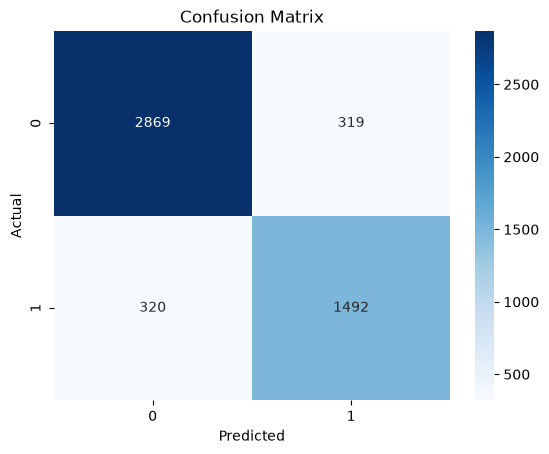

In [63]:
# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# using Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Predict New Student 

In [64]:
# new_student info
new_student = pd.DataFrame({
    'Age': [22],
    'Gender': ['Male'],
    'Degree': ['B.Tech'],
    'Branch': ['Computer Science'],
    'CGPA': [8.2],
    'Internships': [2],
    'Projects': [3],
    'Coding_Skills': [8],
    'Communication_Skills': [8],
    'Aptitude_Test_Score': [82],
    'Soft_Skills_Rating': [8],
    'Certifications': [3],
    'Backlogs': [0]
})

In [65]:
# Predicting new_students' placement
prediction = model.predict(new_student)

print("Placement Prediction:", prediction[0])

Placement Prediction: Placed


C:\Users\Sandeep\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [66]:
# Probability of getting new_student placed
probability = model.predict_proba(new_student)

print("Not Placed:", probability[0][0])
print("Placed:", probability[0][1])

Not Placed: 0.005647192366877385
Placed: 0.9943528076331226


C:\Users\Sandeep\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Conclusion

A Logistic Regression model was developed to predict student placement status using academic performance, skills, internships, projects, and other student-related features.

The data was preprocessed using `ColumnTransformer`, with `StandardScaler` applied to numerical features and `OneHotEncoder` applied to categorical features. The preprocessing and Logistic Regression model were combined using a Pipeline.

The model was evaluated using accuracy, confusion matrix, precision, recall, and F1-score. The trained model can also predict the placement status and placement probability for a new student.